# DS 2500 Exploratory Data Analysis

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sb

import numpy as np
import pandas as pd

pd.options.display.max_columns = 25

# 1. Formulate your questions
Does the proportion of fatal collisions involving alcohol impaired drivers vary by region in th U.S.?

Drunk driving is still one of the biggest causes of traffic deaths in the U.S., killing more than 10,000 poeple a year and people have lots of assumptions about which regions of the United States drink more. The midwest is notorious for bar culture (particularly Wisconsin), while the South has dry counties and the Bible Belt, and Utah barely drinks at all because of the LDS church. I wanted to investigate whether those stereotypes are reflected in the crash data or if drunk diriving is much the same everywhere. It also matters for policy. If one region is significantly worse, it makes sense to focus DUI enforcement and awareness campaigns there. If they're all about the same, we can approach it as a national problem.

The question fits the bad-drivers dataset because it has one row per state (plus DC) and a collumn for the percentage of drivers in fatal collisions who were alcohol impaired. Since it's a percentage and not a raw count, big states like California and Texas don't outright look worse simply becuase they have more drivers, so it's valid to compare across states. The dataset doesn't have a region column, so I added one pulling from the Census Bureau's four regions. This gives us one numeric variable and one categorical variable.


# 2. Read in your data



In [ ]:
drinking_rates_df = pd.read_csv('https://raw.githubusercontent.com/harsh1399/DS2500-Data_Wrangling/main/Module_Assignment-1/Highway_Safety_Data/bad-drivers.csv')
drinking_rates_df = drinking_rates_df.rename(columns={'Percentage Of Drivers Involved In Fatal Collisions Who Were Alcohol-Impaired':'alcohol_collision_pct'})


To answer our question we'll need to assign a region to each state.

In [ ]:
state_to_region = {
    # Northeast (9)
    "Connecticut": "Northeast", "Maine": "Northeast", "Massachusetts": "Northeast",
    "New Hampshire": "Northeast", "Rhode Island": "Northeast", "Vermont": "Northeast",
    "New Jersey": "Northeast", "New York": "Northeast", "Pennsylvania": "Northeast",
    # Midwest (12)
    "Illinois": "Midwest", "Indiana": "Midwest", "Michigan": "Midwest", "Ohio": "Midwest",
    "Wisconsin": "Midwest", "Iowa": "Midwest", "Kansas": "Midwest", "Minnesota": "Midwest",
    "Missouri": "Midwest", "Nebraska": "Midwest", "North Dakota": "Midwest", "South Dakota": "Midwest",
    # South (16 + DC)
    "Delaware": "South", "Florida": "South", "Georgia": "South", "Maryland": "South",
    "North Carolina": "South", "South Carolina": "South", "Virginia": "South",
    "West Virginia": "South", "Alabama": "South", "Kentucky": "South", "Mississippi": "South",
    "Tennessee": "South", "Arkansas": "South", "Louisiana": "South", "Oklahoma": "South",
    "Texas": "South",
    "District of Columbia": "South",
    # West (13)
    "Arizona": "West", "Colorado": "West", "Idaho": "West", "Montana": "West",
    "Nevada": "West", "New Mexico": "West", "Utah": "West", "Wyoming": "West",
    "Alaska": "West", "California": "West", "Hawaii": "West", "Oregon": "West",
    "Washington": "West",
}

drinking_rates_df.insert(loc=1, column='Region', value=drinking_rates_df['State'].map(state_to_region))
drinking_rates_df

,State,Region,Number of drivers involved in fatal collisions per billion miles,Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding,alcohol_collision_pct,Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted,Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents,Car Insurance Premiums ($),Losses incurred by insurance companies for collisions per insured driver ($)
0,Alabama,South,18.8,39,30,96,80,784.55,145.08
1,Alaska,West,18.1,41,25,90,94,1053.48,133.93
2,Arizona,West,18.6,35,28,84,96,899.47,110.35
3,Arkansas,South,22.4,18,26,94,95,827.34,142.39
4,California,West,12.0,35,28,91,89,878.41,165.63
5,Colorado,West,13.6,37,28,79,95,835.50,139.91
6,Connecticut,Northeast,10.8,46,36,87,82,1068.73,167.02
7,Delaware,South,16.2,38,30,87,99,1137.87,151.48
8,District of Columbia,South,5.9,34,27,100,100,1273.89,136.05
9,Florida,South,17.9,21,29,92,94,1160.13,144.18


# 3. Check the packaging

In [ ]:
drinking_rates_df.shape

(51, 9)

# 4. Look at the top and bottom of data

In [ ]:
drinking_rates_df.head()

,State,Region,Number of drivers involved in fatal collisions per billion miles,Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding,alcohol_collision_pct,Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted,Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents,Car Insurance Premiums ($),Losses incurred by insurance companies for collisions per insured driver ($)
0,Alabama,South,18.8,39,30,96,80,784.55,145.08
1,Alaska,West,18.1,41,25,90,94,1053.48,133.93
2,Arizona,West,18.6,35,28,84,96,899.47,110.35
3,Arkansas,South,22.4,18,26,94,95,827.34,142.39
4,California,West,12.0,35,28,91,89,878.41,165.63


In [ ]:
drinking_rates_df.tail()

,State,Region,Number of drivers involved in fatal collisions per billion miles,Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding,alcohol_collision_pct,Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted,Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents,Car Insurance Premiums ($),Losses incurred by insurance companies for collisions per insured driver ($)
46,Virginia,South,12.7,19,27,87,88,768.95,153.72
47,Washington,West,10.6,42,33,82,86,890.03,111.62
48,West Virginia,South,23.8,34,28,97,87,992.61,152.56
49,Wisconsin,Midwest,13.8,36,33,39,84,670.31,106.62
50,Wyoming,West,17.4,42,32,81,90,791.14,122.04


# 5. Check the "n"s

Values should be percentages so make sure they're between 0 and 100

In [ ]:
drinking_rates_df[(drinking_rates_df['alcohol_collision_pct'] < 0) | (drinking_rates_df['alcohol_collision_pct'] > 100)]


,State,Region,Number of drivers involved in fatal collisions per billion miles,Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding,alcohol_collision_pct,Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted,Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents,Car Insurance Premiums ($),Losses incurred by insurance companies for collisions per insured driver ($)


The resulting data frame is empty as expected.

Now since we're talking states we also expect 51 (including D.C)

In [ ]:
len(drinking_rates_df)

51

# 6. Validate against an external knowledge or data source

Culturally, the midwest is infamous for it's prominent drinking culture so we might expect the top of this list to be populated with midwestern states (if we assume higher drinking rates means more fatal collisions involving alcohol.) On the other side of the coin, I know Utah has very low drinking rates because of the LDS church so I'd expect to see it near the bottom. From the results, this is more or less confirmed with a decent number of midwestern states at the top and Utah in dead last.

In [ ]:
drinking_rates_df.sort_values(by='alcohol_collision_pct', ascending=False)

,State,Region,Number of drivers involved in fatal collisions per billion miles,Percentage Of Drivers Involved In Fatal Collisions Who Were Speeding,alcohol_collision_pct,Percentage Of Drivers Involved In Fatal Collisions Who Were Not Distracted,Percentage Of Drivers Involved In Fatal Collisions Who Had Not Been Involved In Any Previous Accidents,Car Insurance Premiums ($),Losses incurred by insurance companies for collisions per insured driver ($)
26,Montana,West,21.4,39,44,84,85,816.21,85.15
34,North Dakota,Midwest,23.9,23,42,99,86,688.75,109.72
11,Hawaii,West,17.5,54,41,82,87,861.18,120.92
40,South Carolina,South,23.9,38,41,96,81,858.97,116.29
39,Rhode Island,Northeast,11.1,34,38,92,79,1148.99,148.58
43,Texas,South,19.4,40,38,91,87,1004.75,156.83
6,Connecticut,Northeast,10.8,46,36,87,82,1068.73,167.02
27,Nebraska,Midwest,14.9,13,35,93,90,732.28,114.82
21,Massachusetts,Northeast,8.2,23,35,87,80,1011.14,135.63
25,Missouri,Midwest,16.1,43,34,92,84,790.32,144.45


# 7. Make a plot


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: title={'center': 'Percentage of Fatal Collisions Involving Alcohol by Region'}, xlabel='Region', ylabel='Alcohol Impaired Drivers in Fatal Collisions (%)'>

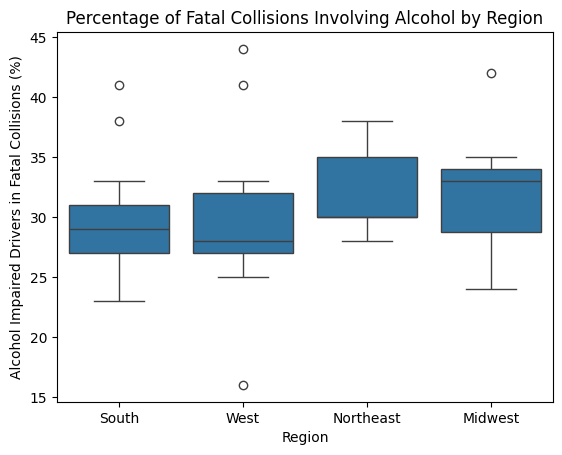

In [ ]:
fig, ax = plt.subplots()
ax.set_title("Percentage of Fatal Collisions Involving Alcohol by Region")
ax.set_ylabel('Alcohol Impaired Drivers in Fatal Collisions (%)')
sns.boxplot(data=drinking_rates_df, x='Region', y='alcohol_collision_pct', ax=ax)

# 8. Try an easy solution



To determine if the mean of alcohol related fatal collisions varies between regions, we'll perform an ANOVA test.

* Null hypotheses: the mean percentage of alcohol related fatal collisions is the same across all four regions.

* Alternative hypotheses: At least on region's mean is different.

For this test we'll use a level of significance of α = 0.05

Below check the following assumptions of an ANOVA test:

* **Independence:** Each state is it's own observation so we don't actually need to perform a test.
* **Normality:** We'll use a Shapiro test to determine if the means of each group are normally distributed. Well also create normal probability plots to visualize the normality.
* **Equal Variance:** We'll use a Levene's test to check for equality of variance.

In [ ]:

# Create a series for of collision percentages for each region
northeast_pct = drinking_rates_df[drinking_rates_df['Region'] == 'Northeast'].alcohol_collision_pct
midwest_pct = drinking_rates_df[drinking_rates_df['Region'] == 'Midwest'].alcohol_collision_pct
west_pct = drinking_rates_df[drinking_rates_df['Region'] == 'West'].alcohol_collision_pct
south_pct = drinking_rates_df[drinking_rates_df['Region'] == 'South'].alcohol_collision_pct


Normality Test:

In [ ]:
import scipy
shapiro_pvals= {}
shapiro_pvals['northeast']=scipy.stats.shapiro(northeast_pct).pvalue
shapiro_pvals['midwest']=scipy.stats.shapiro(midwest_pct).pvalue
shapiro_pvals['west']=scipy.stats.shapiro(west_pct).pvalue
shapiro_pvals['south']=scipy.stats.shapiro(south_pct).pvalue



True
True
True
True


For the shaprio test, a p value > 0.05 indicates no evidence against normality. All our p values are well over 0.05 so we can assume normality.

Normal Probability Plot

[Text(47.222222222222214, 0.5, ''),
 Text(0.5, 225.12222222222223, ''),
 Text(340.1287878787879, 0.5, ''),
 Text(0.5, 225.12222222222223, ''),
 Text(47.222222222222214, 0.5, ''),
 Text(0.5, 23.52222222222222, ''),
 Text(340.1287878787879, 0.5, ''),
 Text(0.5, 23.52222222222222, '')]

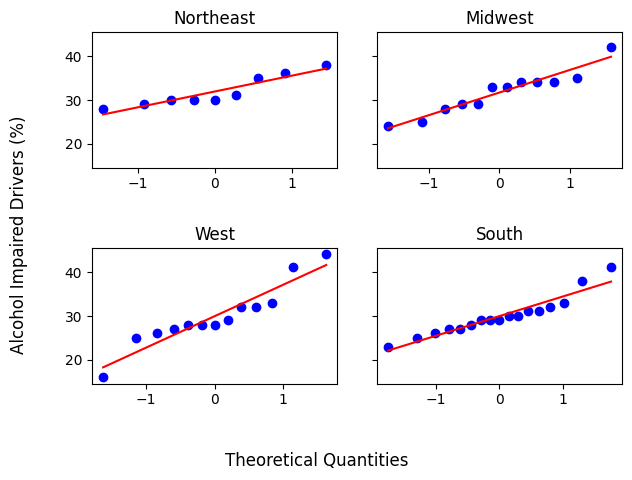

In [ ]:
probplots, probplots_ax = plt.subplots(2, 2, sharey=True)
probplots.supylabel('Alcohol Impaired Drivers (%)')
probplots.supxlabel('Theoretical Quantiles')

scipy.stats.probplot(northeast_pct, plot=probplots_ax[0,0])
probplots_ax[0,0].set_title('Northeast')
scipy.stats.probplot(midwest_pct, plot=probplots_ax[0,1])
probplots_ax[0,1].set_title('Midwest')
scipy.stats.probplot(west_pct, plot=probplots_ax[1,0])
probplots_ax[1,0].set_title('West')
scipy.stats.probplot(south_pct, plot=probplots_ax[1,1])
probplots_ax[1,1].set_title('South')
probplots.tight_layout()
plt.setp(probplots_ax, ylabel='', xlabel='')




Levene's Test

A p-value > 0.05 indicates no evidence the variances differ.

In [ ]:
scipy.stats.levene(northeast_pct, midwest_pct, west_pct, south_pct)

LeveneResult(statistic=np.float64(0.6491471342724385), pvalue=np.float64(0.5874357639512314))

All our assumption tests passed so we're clear to perform the ANOVA

In [ ]:
scipy.stats.f_oneway(northeast_pct, midwest_pct, west_pct, south_pct)

F_onewayResult(statistic=np.float64(0.510510969813795), pvalue=np.float64(0.676981732577743))

# Writeup

For this EDA I wanted to find out if the percentage of fatal collisions involving alcohol impaired drivers differs depending on which region of the U.S. you're in. I chose this because I've heard lots of stereotypes about drinking in different parts of the country and I wanted to see if the crash data actually reflects them.

The data is the bad-drivers dataset from the Highway Safety data. It has one row for each state plus DC, and I read it directly from the raw CSV github link. For convenience, I renamed the long alcohol column name to alcohol_collision_pct then used a dictionary to map each state to a region (I put DC in the South, per the Census Bureau). That resulted in 9 states in the Northeast, 12 in the Midwest, 17 in the South, and 13 in the West. Anyone rerunning this just needs the raw CSV link and the dictionary provided in this notebook.

Next I went through the EDA checklist. The shape was (5,19) after adding Region, and the head and tail looked as expected. For the n's I checked that every percentage was between 0 and 100 (the filter came back empty as expected) and that there were 51 rows. To validate against outside knowledge, I sort the stated by the alcohol column. I expected Utah near the bottom on account of the LDS church, and it was. The Midwest also had the highest median, which is in line with its drinking reputation.

For the visualization  imade a box plot with region on the x axis and alcohol percentage on the y axis. I went with a box plot because I'm comparing four groups containing between 9 and 17 states each. When I tried a bar chart of means you couldn't really grasp the spread and outliers. The boxes mostly overlap. The Northeast and Midwest are a little higher, and the West has the largest spread because of Utah at the bottom and Montana and Hawaii at the top.

To test the data I used a one-way ANOVA since I'm comparing the means of one numeric variable across more than two independent groups. The null hypothesis is the mean percentage is the same in all four regions and the alternative is that at least one region's mean is different, using α = 0.05. I checked the three assumptions of an ANOVA test first. Independence is fine since each state is its own observation. For normalite, I ran Shapiro-Wilk on each region and all four p-values were above 0.05, so no evidence against normality. The normal probability plots mostly follow the line as well. Leven's test gave p = 0.587, so our equal variance assumption passed too.

THe anove gave F = 0.51 and p 0.677, which is well above 0.05, so I fail to reject the null. There's no statistically significant difference between regions. The means were all withing about two points of eachother, which agrees with the box plot.

In conclusion, drunk driving looks like a national problem more than a regional one. Around 30% of drivers in fatal crashes were alcohol impaired across all regions, and the two extreme outliers (Utah and Montana) both lie in the same region. However, there are some limitations to this analysis. The groups are small so the test can't detect minute difference well, and state averages hide the variations within each state. If I did this again I'd look at things like state DUI laws or how rural a state is instead of region.

# Reflection
The data ethics canvas was somewhat useful for my dataset, primarily the top row about data sources and limitations. My data is public and only at the state level with no personal information, so "righs around data sources" wasn't much of a concern. The 'limiations' box made me think about what the alcohol number actually means though. "Alcohol impaired" depends on BAC testing, and not every driver in a fatal collision gets tested for blood alcohol, so a state that's more stringent with sobriety tests may look worse simple because they catch more drunk drivers. The dataset also doesn't say what year i'ts from or where the numbers originally came from.

For a real world example, the first thing that came to mind was Flock Safety, which makes the license plate reader cameras in widespread use across the U.S.. Police departments can share that data with other agencies around the country. The Washington Post documented nearly 50 cases of officers accused of misusing the system, often to track former partners or family members. In Auguest Flock cut is default data retention from 30 days to 7 and mandated search audits. Critics like the ACLU and the Institute for Justice said the changes were mostly for show, since it's still just the police who investigate themselves. More than 50 agencies have canceled or suspended contracts since January. If anyone had gone through the data ethics canvas's "negative effects on people" and "sharing data with others" boxes before deploying Flock, the stalking concern would have been immediate since drivers never consented to being tracked. Compared to my dataset which is just state averages, it illustrates that this kind of thought process becomes more important the closer the data gets to real people.